In [5]:
import sys
!{sys.executable} -m pip install --user xgboost imbalanced-learn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 9.0 MB/s eta 0:00:12
    --------------------------------------- 2.1/101.7 MB 7.2 MB/s eta 0:00:14
   - -------------------------------------- 3.4/101.7 MB 7.5 MB/s eta 0:00:14
   -- ------------------------------------- 5.5/101.7 MB 7.4 MB/s eta 0:00:13
   -- ------------------------------------- 7.1/101.7 MB 7.4 MB/s eta 0:00:13
   --- ------------------------------------ 8.4/101.7 MB 7.4 MB/s eta 0:00:13
   --- ------------------------------------ 10.0/101.7 MB 7.2 MB/s eta 0:00:13
   ---- ----------------------------------- 11.5/101.7 MB 7.2 MB/s eta 0:00:13
   ----- ---------------------------------- 13.1/101.7 MB 7.3 MB/s eta 0:00:13
   ----- ---------------------------------- 14.4/101.7 MB 7.3 MB/s eta 0:00:13
   ----- ---------------------------------- 14.7/101.7 MB 6.8 MB/s eta 0:00:13
   ------ --------------------------------- 16.5/101.7 MB 6.7 MB/s

Dataset Shape: (10000, 16)
fraud_label
0    0.8498
1    0.1502
Name: proportion, dtype: float64

--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1700
           1       0.14      0.18      0.16       300

    accuracy                           0.72      2000
   macro avg       0.50      0.49      0.49      2000
weighted avg       0.74      0.72      0.73      2000

ROC-AUC Score: 0.5032


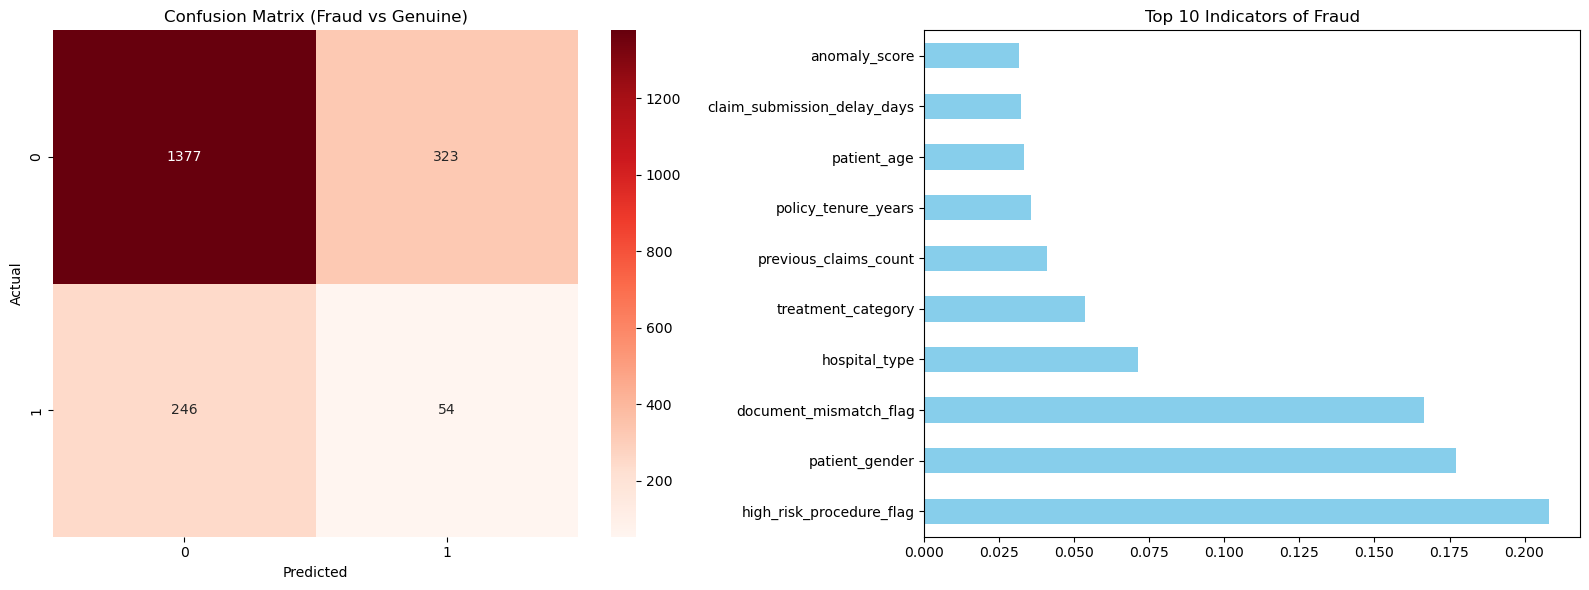

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# 1. Load the dataset
# Ensure the file is in the same folder as your notebook
df = pd.read_csv('AI_Based_Medical_Insurance_Claim_Fraud_Detection_Dataset.csv')

# 2. Exploratory Data Analysis (Quick Look)
print(f"Dataset Shape: {df.shape}")
print(df['fraud_label'].value_counts(normalize=True)) # Check for imbalance

# 3. Feature Engineering
# Creating a ratio of approved vs claimed amount can be a strong fraud indicator
if 'claim_amount' in df.columns and 'approved_amount' in df.columns:
    df['unapproved_ratio'] = (df['claim_amount'] - df['approved_amount']) / (df['claim_amount'] + 1)

# 4. Data Preprocessing
# Drop unique IDs that don't help in prediction
df_ml = df.drop(columns=['claim_id'], errors='ignore')

# Encode Categorical columns (Gender, Hospital Type, Treatment Category, etc.)
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# Define Features and Target
X = df_ml.drop('fraud_label', axis=1)
y = df_ml['fraud_label']

# 5. Handling Class Imbalance (SMOTE)
# Fraud datasets are usually heavily skewed towards '0' (No Fraud)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 6. Model Training (XGBoost)
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss'
)

model.fit(X_train_res, y_train_res)

# 7. Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 8. Visualizing Results
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title('Confusion Matrix (Fraud vs Genuine)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Feature Importance
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', ax=ax[1], color='skyblue')
ax[1].set_title('Top 10 Indicators of Fraud')

plt.tight_layout()
plt.show()

In [8]:
import joblib

# Save the model
joblib.dump(model, 'fraud_detection_model.pkl')

print("Model saved successfully!")

Model saved successfully!
